## MODIS MOD13Q1 NDVI/EVI time series & rice-paddy phenology

MODIS's MOD13Q1.061 product distributes 250 m, 16-day-composite NDVI and EVI globally,
with a daily-revisit sensor behind it (Terra) -- the tradeoff against HLS's 30 m is
resolution for temporal frequency. This notebook uses that frequency to look at
something the [`hls_l30_s30`](../hls_l30_s30/) tutorial's single scene pair couldn't:
the *shape of a growing season* over multiple years, for a fixed AOI.

**AOI**: Honam plain, South Korea -- contiguous rice-paddy cropland 

**Record**: 207 sixteen-day composites, 2017-06-26 to 2026-06-10 (~9 years)

1. Load the AppEEARS NetCDF export and inspect its spatial/temporal extent
2. Mask unreliable composites (cloud/snow/fill) via Pixel Reliability
3. Build an AOI-mean NDVI/EVI time series across the full multi-year record
4. Zoom into one representative year and compare the NDVI vs. EVI seasonal curves
5. Extract simple start/peak/end-of-season dates from the curve
6. Plot a single-date NDVI snapshot as a map, directly in longitude/latitude

### Data

MOD13Q1.061 (NDVI, EVI, Pixel Reliability, Composite Day of the Year), requested via
[AppEEARS](https://appeears.earthdatacloud.nasa.gov/) as an Area sample, Geographic
projection, exported as NetCDF. See `README.md` in this folder for the exact layers and
how to point this notebook at your own download via `MODIS_NC_PATH`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))
import MODIS

NC_PATH = os.environ.get(
    "MODIS_NC_PATH", os.path.join("data", "MOD13Q1.061_250m_aid0001.nc")
)
AOI_BBOX = (126.70, 35.65, 127.05, 35.95)  # west, south, east, north -- Honam plain rice paddies

reader = MODIS.VITimeSeriesReader(NC_PATH)
print(f"Grid: {reader.lat.size} x {reader.lon.size} pixels")
print(f"Lon range: {reader.lon.min():.3f} to {reader.lon.max():.3f}")
print(f"Lat range: {reader.lat.min():.3f} to {reader.lat.max():.3f}")
print(f"Time range: {reader.time[0].strftime('%Y-%m-%d')} to {reader.time[-1].strftime('%Y-%m-%d')} ({len(reader.time)} composites)")

Grid: 524 x 515 pixels
Lon range: 126.655 to 127.726
Lat range: 35.401 to 36.491
Time range: 2017-06-26 to 2026-06-10 (207 composites)


### 1. Mask unreliable composites via Pixel Reliability

Each 16-day composite carries a Pixel Reliability rank (Good / Marginal / Snow-Ice /
Cloudy / Fill). `MODIS.is_reliable` keeps Good and Marginal by default -- the same
"reusable, shared QA decoder" pattern as `HLS.is_cloud` in the other tutorial, just for
a ranked QA layer instead of a bitmask.

In [2]:
ndvi = reader.ndvi()  # masked via Pixel Reliability by default
evi = reader.evi()

reliability = reader.reliability()
valid_fraction = MODIS.is_reliable(reliability.values).mean()
print(f"Fraction of all pixel-dates rated Good/Marginal: {valid_fraction:.1%}")

Fraction of all pixel-dates rated Good/Marginal: 91.8%


### 2. AOI-mean time series across the full record

Averaging over the AOI at each date washes out most of the per-pixel cloud/snow gaps,
giving a (nearly) continuous seasonal curve across all ~9 years on record.

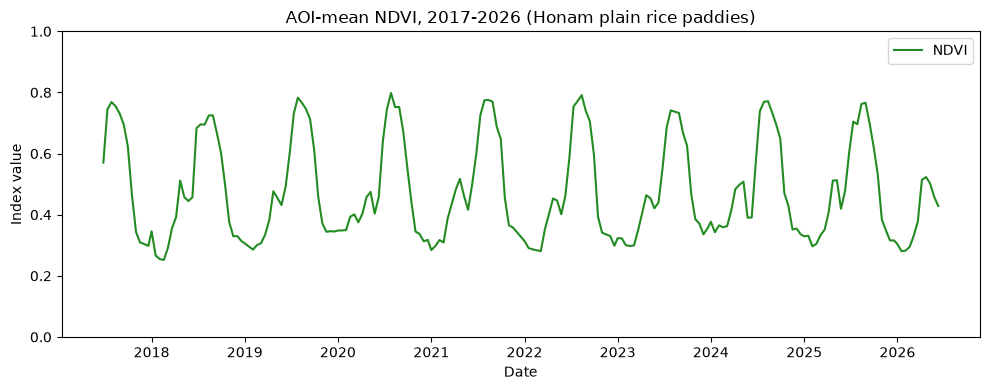

In [3]:
ndvi_roi = reader.roi_mean(ndvi, bbox=AOI_BBOX)
evi_roi = reader.roi_mean(evi, bbox=AOI_BBOX)

plotter = MODIS.VIPlotter(reader)
ax = plotter.plot_timeseries(ndvi_roi, label="NDVI", color="forestgreen")
ax.set_title("AOI-mean NDVI, 2017-2026 (Honam plain rice paddies)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 3. One representative year: NDVI vs. EVI

Zooming into a single year makes the rice-paddy signal clear: a dip in May-June as
fields are flooded for transplanting (vegetation signal briefly *drops* even though
this is the start of the growing season), a rapid rise through summer, a peak in
August, and a sharp decline as fields are harvested in October.

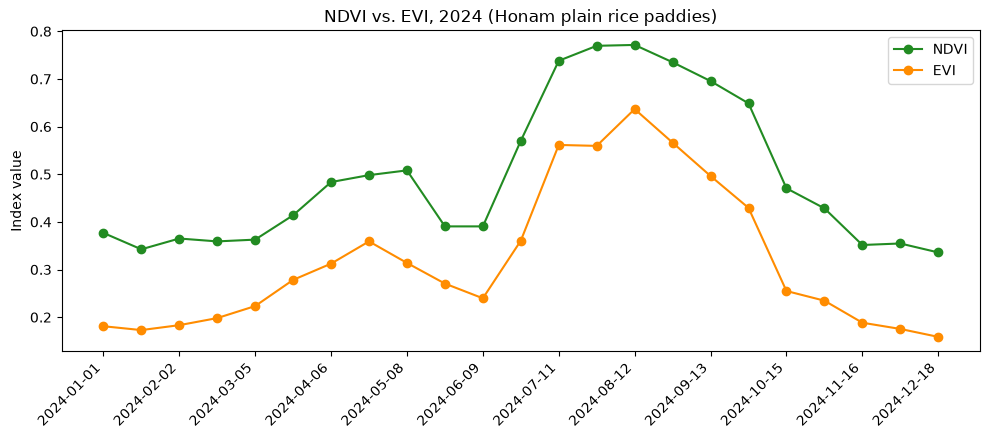

In [4]:
YEAR = "2024"
ndvi_year = ndvi_roi.sel(time=slice(f"{YEAR}-01-01", f"{YEAR}-12-31"))
evi_year = evi_roi.sel(time=slice(f"{YEAR}-01-01", f"{YEAR}-12-31"))
dates_year = [t.strftime("%Y-%m-%d") for t in ndvi_year.time.values]

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(dates_year))
ax.plot(x, ndvi_year.values, marker="o", label="NDVI", color="forestgreen")
ax.plot(x, evi_year.values, marker="o", label="EVI", color="darkorange")
ax.set_xticks(x[::2])
ax.set_xticklabels(dates_year[::2], rotation=45, ha="right")
ax.set_ylabel("Index value")
ax.set_title(f"NDVI vs. EVI, {YEAR} (Honam plain rice paddies)")
ax.legend()
plt.tight_layout()
plt.show()

### 4. Extracting start / peak / end of season

A simple, illustrative amplitude-threshold method: take the year's NDVI range, set the
threshold at the bottom 20% of that range (a common rule of thumb in phenology
literature), and find where the curve first rises above it before the peak (start of
season) and first falls back below it after the peak (end of season). This is not a
validated phenology algorithm -- treat the dates as approximate.

Start of season:  2024-06-25  (NDVI=0.570)
Peak:             2024-08-12  (NDVI=0.771)
End of season:    2024-10-31  (NDVI=0.428)
Season length:    9 composites (~144 days)


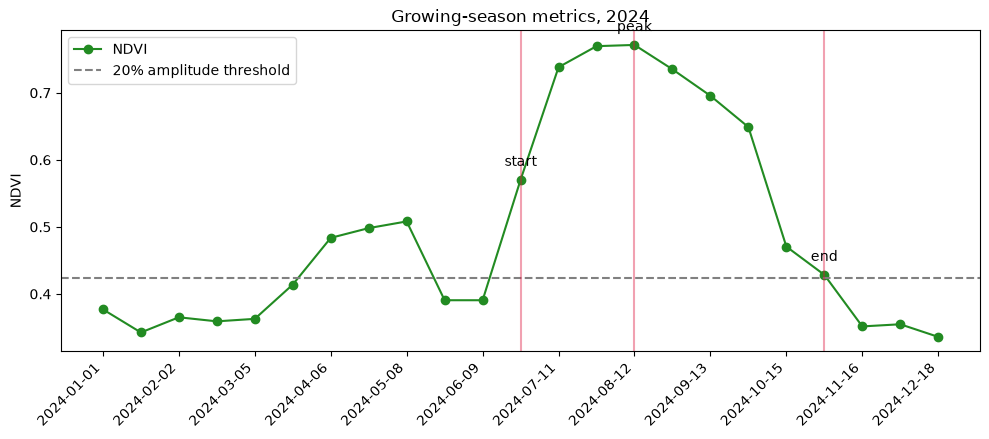

In [5]:
values = ndvi_year.values
vmin, vmax = np.nanmin(values), np.nanmax(values)
threshold = vmin + 0.2 * (vmax - vmin)
peak_idx = int(np.nanargmax(values))
above = values >= threshold

sos_idx = peak_idx
while sos_idx > 0 and above[sos_idx - 1]:
    sos_idx -= 1
eos_idx = peak_idx
while eos_idx < len(values) - 1 and above[eos_idx + 1]:
    eos_idx += 1

print(f"Start of season:  {dates_year[sos_idx]}  (NDVI={values[sos_idx]:.3f})")
print(f"Peak:             {dates_year[peak_idx]}  (NDVI={values[peak_idx]:.3f})")
print(f"End of season:    {dates_year[eos_idx]}  (NDVI={values[eos_idx]:.3f})")
print(f"Season length:    {eos_idx - sos_idx + 1} composites (~{16 * (eos_idx - sos_idx + 1)} days)")

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(dates_year))
ax.plot(x, values, marker="o", color="forestgreen", label="NDVI")
ax.axhline(threshold, color="gray", linestyle="--", label="20% amplitude threshold")
for idx, label in ((sos_idx, "start"), (peak_idx, "peak"), (eos_idx, "end")):
    ax.axvline(idx, color="crimson", alpha=0.4)
    ax.annotate(label, (idx, values[idx]), textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_xticks(x[::2])
ax.set_xticklabels(dates_year[::2], rotation=45, ha="right")
ax.set_ylabel("NDVI")
ax.set_title(f"Growing-season metrics, {YEAR}")
ax.legend()
plt.tight_layout()
plt.show()

### 5. A single-date map, directly in longitude/latitude

AppEEARS already reprojected this product to Geographic (WGS84) for us, so -- unlike the
HLS tutorial's UTM-gridded rasters -- no reprojection or tick-relabeling trick is needed
here; `lon`/`lat` are true coordinates already.

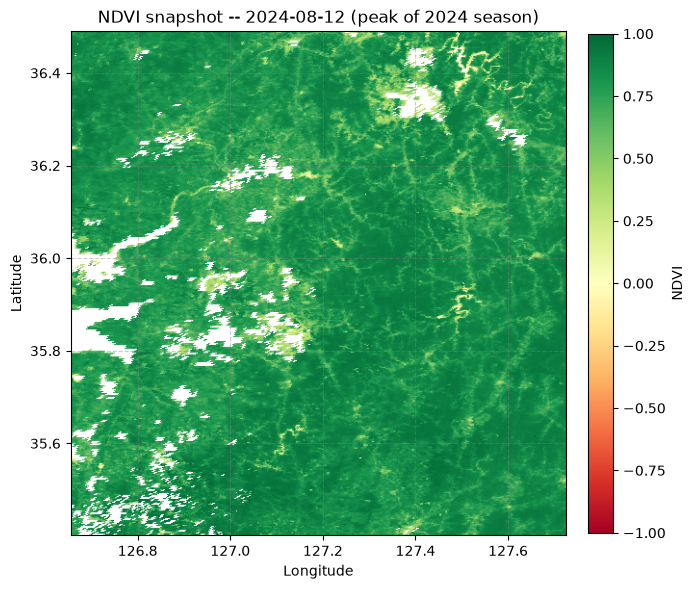

In [6]:
peak_date = ndvi_year.time.values[peak_idx]
snapshot = ndvi.sel(time=peak_date)

fig, ax = plotter.plot_map(
    snapshot.values,
    title=f"NDVI snapshot -- {dates_year[peak_idx]} (peak of {YEAR} season)",
    colorbar_label="NDVI",
)
plt.show()

## Summary

- MODIS trades HLS's 30 m resolution for a dense, regular 16-day revisit -- exactly what
  a *time series* / phenology question needs, and what a single HLS scene pair cannot
  answer on its own.
- The rice-paddy signal here is a textbook case: NDVI briefly *drops* in May-June as
  fields are flooded for transplanting, then rises quickly through summer to an August
  peak before a sharp October harvest decline.
- AppEEARS' Geographic-projection export means this whole notebook works in true
  longitude/latitude throughout -- no UTM handling needed, unlike the HLS tutorial.
- The start/peak/end-of-season extraction here is a simple, illustrative
  amplitude-threshold method, not a validated phenology algorithm; it's a reasonable
  first pass, not a research-grade result.